# SVM Classification in Python with scikit-learn

**Goal:** use a Support Vector Machine to predict gender from height and weight, using the same dataset and train/test split as the logistic regression notebook so the two can be compared.

## 1. Data exploration

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set()

file_name = "heights_weights.csv"
df = pd.read_csv(file_name)
df.head()

,Height,Weight,Male
0,73.847017,241.893563,1
1,68.781904,162.310473,1
2,74.110105,212.740856,1
3,71.730978,220.042470,1
4,69.881796,206.349801,1


In [2]:
print("Shape:", df.shape)
df.describe()

Shape: (10000, 3)


,Height,Weight,Male
count,10000.000000,10000.000000,10000.000000
mean,66.367560,161.440357,0.500000
std,3.847528,32.108439,0.500025
min,54.263133,64.700127,0.000000
25%,63.505620,135.818051,0.000000
50%,66.318070,161.212928,0.500000
75%,69.174262,187.169525,1.000000
max,78.998742,269.989699,1.000000


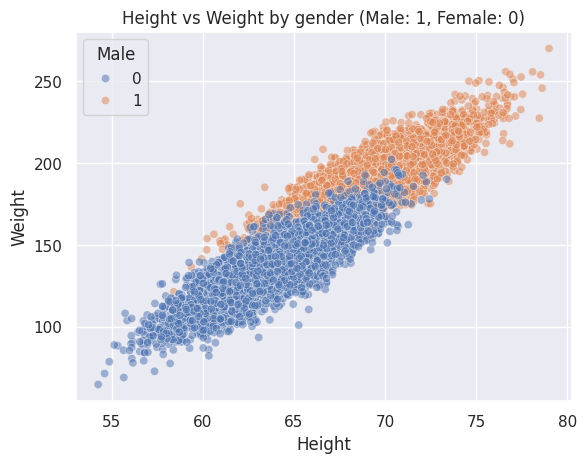

In [3]:
ax = sns.scatterplot(x="Height", y="Weight", hue="Male", data=df, alpha=0.5)
ax.set_title("Height vs Weight by gender (Male: 1, Female: 0)")
plt.show()

## 2. Get the data ready for training

In [4]:
from sklearn.model_selection import train_test_split

# Features: Height, Weight  |  Target: Male
x = df.iloc[:, 0:2].values
y = df.iloc[:, 2].values

X_train, X_test, Y_train, Y_test = train_test_split(
    x, y, test_size=0.3, random_state=0
)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

Train size: 7000 | Test size: 3000


In [5]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

## 3. Support Vector Machine performance

`SVC()` defaults to the RBF kernel, which can learn curved boundaries. It finds the boundary that maximises the margin between the two classes.

In [6]:
svm_clf = SVC()
svm_model = svm_clf.fit(X_train, Y_train)
svm_prediction = svm_clf.predict(X_test)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(Y_test, svm_prediction)))
print()
print("Confusion matrix (rows = actual, columns = predicted):")
print(confusion_matrix(Y_test, svm_prediction))
print()
print(classification_report(Y_test, svm_prediction, target_names=["Female", "Male"]))

Accuracy 91.40%

Confusion matrix (rows = actual, columns = predicted):
[[1382  107]
 [ 151 1360]]

              precision    recall  f1-score   support

      Female       0.90      0.93      0.91      1489
        Male       0.93      0.90      0.91      1511

    accuracy                           0.91      3000
   macro avg       0.91      0.91      0.91      3000
weighted avg       0.91      0.91      0.91      3000



## 4. Try different kernels

The kernel controls the shape of the decision boundary. A `linear` kernel gives a straight line like logistic regression; `rbf` and `poly` allow curves.

In [7]:
results = {}
for kernel in ["linear", "rbf", "poly"]:
    model = SVC(kernel=kernel)
    model.fit(X_train, Y_train)
    results[kernel] = accuracy_score(Y_test, model.predict(X_test))

for kernel, acc in results.items():
    print(f"{kernel:>7}: {100 * acc:.2f}%")

 linear: 91.93%
    rbf: 91.40%
   poly: 91.67%


## 5. Visualise the SVM decision boundary

We plot the regions predicted as Male and Female by the default RBF SVM.

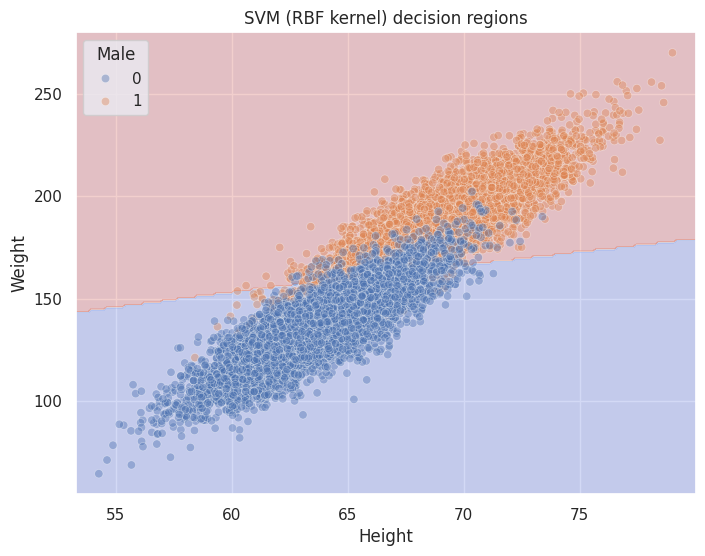

In [8]:
h_min, h_max = df["Height"].min() - 1, df["Height"].max() + 1
w_min, w_max = df["Weight"].min() - 10, df["Weight"].max() + 10
xx, yy = np.meshgrid(np.linspace(h_min, h_max, 200),
                     np.linspace(w_min, w_max, 200))

Z = svm_clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
sns.scatterplot(x="Height", y="Weight", hue="Male", data=df, alpha=0.4)
plt.title("SVM (RBF kernel) decision regions")
plt.show()

## 6. Compare with logistic regression

Run this cell to train both models on the same split and compare accuracy directly.

In [9]:
from sklearn import linear_model

logreg = linear_model.LogisticRegression(C=1e40, solver="newton-cg").fit(X_train, Y_train)

print("Logistic regression accuracy: {0:.2f}%".format(100 * accuracy_score(Y_test, logreg.predict(X_test))))
print("SVM (RBF) accuracy:           {0:.2f}%".format(100 * accuracy_score(Y_test, svm_prediction)))

Logistic regression accuracy: 91.87%
SVM (RBF) accuracy:           91.40%


## Summary

- SVMs choose the boundary with the largest margin between classes; kernels let them fit non-linear boundaries.
- On this dataset the classes are close to linearly separable, so SVM and logistic regression usually score very similarly.